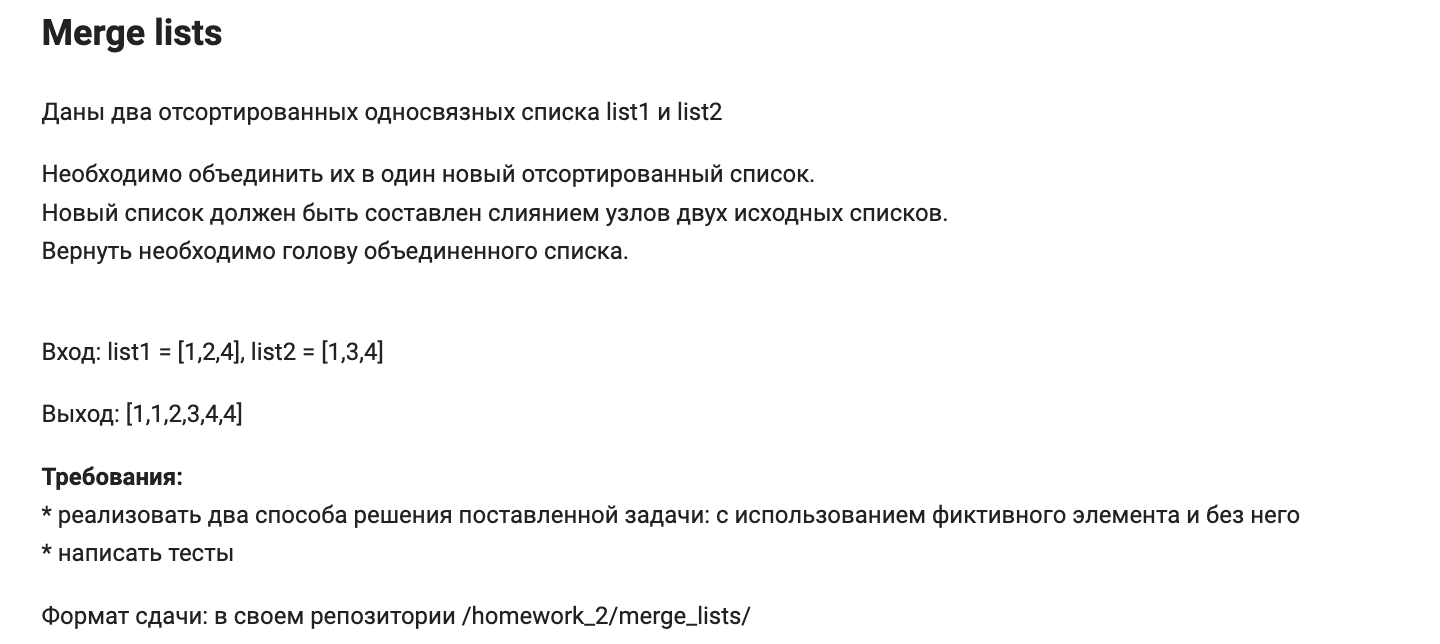

## Ход решения

В задаче нужно слить два уже отсортированных односвязных списка. Поэтому каждый раз достаточно сравнивать только текущие первые ноды `list1` и `list2`: меньшую прицепляем к результату и сдвигаем указатель в том списке, откуда её взяли.

Реализуем два варианта: с фиктивной нодой `dummy` и без неё.

### С `dummy`

Основной смысл начать с какой-то одиночной фиктивной ноды, к которой мы будем прицеплять наши односвязные списки.

Инициализируем её рандомным значением, потом все равно от неё избавимся. Далее создаём вторую переменную `current`: она будет указывать, где именно мы находимся в объединённом списке, в то время как dummy сохранит начальное положение.

- Сравниваем текущие значения в двух списках, пока **оба списка не пустые**, если хотя бы один опустел - останавливаемся.
- Прицепляем к `current.next` ноду с меньшим значением.
- Затем обрезаем необработанный остаток этого списка (списка откуда достали ноду): сдвигаем его указатель на следующую ноду.
- Сдвигаем `current`, потому что следующий элемент уже нужно присоединять к только что добавленной ноде.
- Продолжаем, пока один из списков не закончится.
- Когда один из списков закончился, остаток второго списка целиком присоединяем к `current.next`. Там исходя из построения задачки будут все значения строго больше, чем до этого. Если оба списка закончились одновременно, присоединится `None`, то есть ничего не ломается.
- В конце возвращаем `dummy.next`: `dummy` нужен именно для того, чтобы не потерять начало результата, а сама фиктивная нода в ответ входить не должна, поэтому берем `next`

### Без `dummy`

Тут уже мы не можем начать с фиктивной ноды, поэтому необходимо отдельно определить голову результата, т.е место, откуда начнем.

- Сначала проверяем пустые списки. Если один из них пустой, сразу возвращаем другой.
- В случае двух пустых, выведется просто пустой список (как и должно быть).
- Затем находим первую наименьшую ноду и сохраняем её в `head`. `head` больше не двигаем - он запоминает начало объединённого списка. По аналогии с dummy раннее, лишь с небольшим отличием, что head является элементом одного из списков.
- Указатель того списка, откуда взяли первую ноду, сдвигаем вперёд.
- `current` ставим на `head` и дальше повторяем ту же логику: сравниваем текущие ноды, прицепляем меньшую и сдвигаем соответствующий список.
- Когда один список заканчивается, присоединяем остаток второго.
- Возвращаем `head`.

## Сложность алгоритма

Пусть в первом списке `n` нод, а во втором — `m`.

Каждая нода обрабатывается не более одного раза, поэтому:

| Решение | Время | Доп. память |
| --- | ---: | ---: |
| С `dummy` | `O(n + m)` | `O(1)` |
| Без `dummy` | `O(n + m)` | `O(1)` |

Новые ноды для элементов результата не создаются: мы переиспользуем ноды исходных списков и меняем связи между ними. В варианте с `dummy` создаётся только одна фиктивная нода, поэтому дополнительная память всё равно `O(1)`.

# Реализация

Сначала реализуем ноду односвязного списка.

In [1]:
class Node:
    def __init__(self, val, next_node=None):
        self.val = val
        self.next = next_node

### Решение с `dummy`

In [2]:
def merge_dummy(list1: Node | None, list2: Node | None) -> Node | None:
    dummy = Node(0)
    current = dummy

    while list1 is not None and list2 is not None:
        if list1.val <= list2.val:
            current.next = list1
            list1 = list1.next
        else:
            current.next = list2
            list2 = list2.next

        current = current.next

    if list1 is not None:
        current.next = list1
    else:
        current.next = list2

    return dummy.next

### Решение без `dummy`

In [3]:
def merge_without_dummy(list1: Node | None, list2: Node | None) -> Node | None:
    if list1 is None:
        return list2

    if list2 is None:
        return list1

    if list1.val <= list2.val:
        head = list1
        list1 = list1.next
    else:
        head = list2
        list2 = list2.next

    current = head

    while list1 is not None and list2 is not None:
        if list1.val <= list2.val:
            current.next = list1
            list1 = list1.next
        else:
            current.next = list2
            list2 = list2.next

        current = current.next

    if list1 is not None:
        current.next = list1
    else:
        current.next = list2

    return head

# Визуализация работы алгоритма

Возьмём пример:

```text
list1 = 1 -> 2 -> 4
list2 = 1 -> 3 -> 4
```

Покажем вариант с `dummy`. `dummy` всё время остаётся в начале, а `current` двигается по уже собранной части списка.

| Шаг | `list1.val` | `list2.val` | Что берём | Собранная часть |
| ---: | ---: | ---: | --- | --- |
| 0 | `1` | `1` | — | `[]` |
| 1 | `1` | `1` | `1` из `list1` | `[1]` |
| 2 | `2` | `1` | `1` из `list2` | `[1, 1]` |
| 3 | `2` | `3` | `2` из `list1` | `[1, 1, 2]` |
| 4 | `4` | `3` | `3` из `list2` | `[1, 1, 2, 3]` |
| 5 | `4` | `4` | `4` из `list1` | `[1, 1, 2, 3, 4]` |

После пятого шага `list1` закончился:

```text
list1 = None
list2 = 4 -> None
```

Цикл завершается, и оставшийся хвост `list2` целиком прицепляется к `current.next`.

Итоговая цепочка:

```text
dummy -> 1 -> 1 -> 2 -> 3 -> 4 -> 4 -> None
          ^
          |
       dummy.next
```

Возвращаем `dummy.next`, поэтому получаем:

```text
1 -> 1 -> 2 -> 3 -> 4 -> 4 -> None
```

В решении без `dummy` логика слияния такая же, только начало результата заранее сохраняется в `head`.

# Тесты

Проверим оба решения на одинаковом наборе случаев:

- пример из условия;
- оба списка пустые;
- пустой первый список;
- пустой второй список;
- по одному элементу в разном порядке;
- списки, которые полностью идут один за другим;
- отрицательные значения;
- повторяющиеся значения;
- несколько чередований между списками;
- что результат действительно состоит из исходных нод, а не из заново созданных.

In [4]:
def build_list(values):
    head = None
    current = None

    for value in values:
        node = Node(value)

        if head is None:
            head = node
        else:
            current.next = node

        current = node

    return head


def to_list(head):
    result = []

    while head is not None:
        result.append(head.val)
        head = head.next

    return result


def get_nodes(head):
    nodes = []

    while head is not None:
        nodes.append(head)
        head = head.next

    return nodes

In [5]:
test_cases = [
    ([1, 2, 4], [1, 3, 4], [1, 1, 2, 3, 4, 4]),
    ([], [], []),
    ([], [1, 2, 3], [1, 2, 3]),
    ([1, 2, 3], [], [1, 2, 3]),
    ([1], [2], [1, 2]),
    ([2], [1], [1, 2]),
    ([1, 2, 3], [4, 5, 6], [1, 2, 3, 4, 5, 6]),
    ([4, 5, 6], [1, 2, 3], [1, 2, 3, 4, 5, 6]),
    ([-5, -1, 7], [-3, 0, 2], [-5, -3, -1, 0, 2, 7]),
    ([1, 1, 3], [1, 2, 2], [1, 1, 1, 2, 2, 3]),
    ([1, 4, 7, 10], [2, 3, 8, 9], [1, 2, 3, 4, 7, 8, 9, 10]),
]

for merge in (merge_dummy, merge_without_dummy):
    for values1, values2, expected in test_cases:
        list1 = build_list(values1)
        list2 = build_list(values2)

        result = merge(list1, list2)

        assert to_list(result) == expected

print("Основные и граничные тесты пройдены")

Основные и граничные тесты пройдены


In [6]:
for merge in (merge_dummy, merge_without_dummy):
    list1 = build_list([1, 2, 4])
    list2 = build_list([1, 3, 4])

    original_nodes = get_nodes(list1) + get_nodes(list2)
    result = merge(list1, list2)
    result_nodes = get_nodes(result)

    assert len(result_nodes) == len(original_nodes)
    assert {id(node) for node in result_nodes} == {id(node) for node in original_nodes}

print("Проверка переиспользования исходных нод пройдена")

Проверка переиспользования исходных нод пройдена
